In [1]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import pairwise_distances_argmin
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import FancyArrowPatch

In [2]:
# Load dataset
df = pd.read_csv('dataset.csv')

# Describe dataset
print(df.info())
display(df.describe())

# Check missing values 
print("Missing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Missing Values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [3]:
# Check distribution of track_genre
genre_counts = df['track_genre'].value_counts()
print(f"Total counts of genre: {len(genre_counts)}")
print(genre_counts.head(20))

Total counts of genre: 114
track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
chill            1000
classical        1000
club             1000
comedy           1000
country          1000
Name: count, dtype: int64


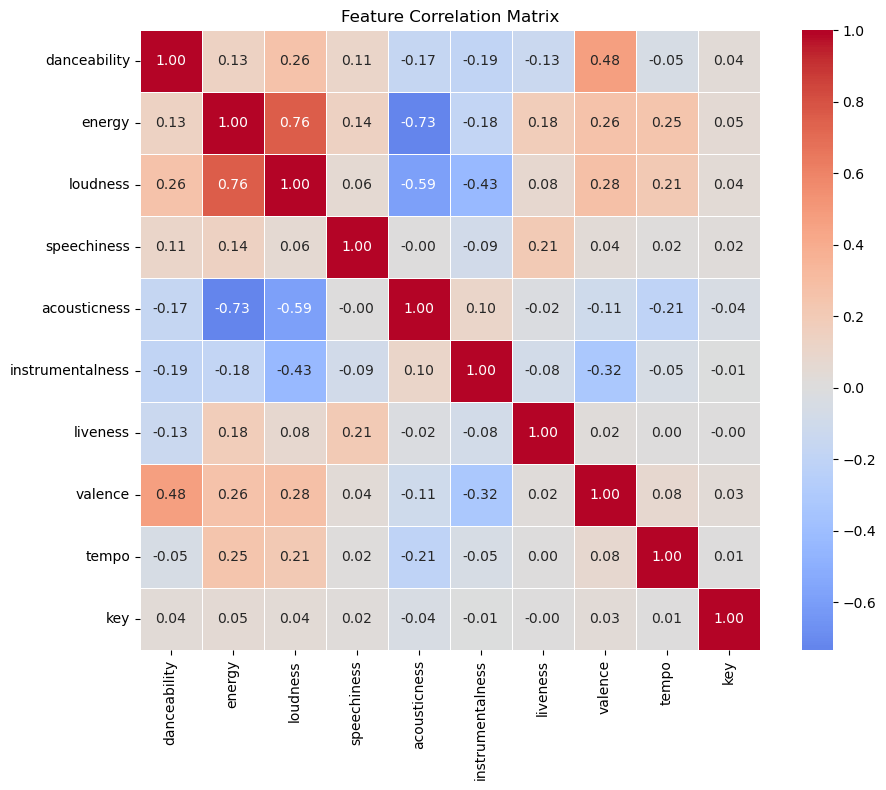

In [4]:
# Check correlations between acoustic features
FEATURES = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'key'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[FEATURES].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()

In [5]:
# Remove loudness (because of being redundant) and key (because of being noise)
FEATURES = [
    'danceability', 'energy', 'speechiness',
    'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo'
]

META = ['track_id', 'artists', 'track_name', 'track_genre']

data = df[FEATURES].copy()
df_meta = df[META].copy()

In [6]:
# Standardize the values 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print(pd.DataFrame(data_scaled, columns=FEATURES).describe().round(2))

       danceability     energy  speechiness  acousticness  instrumentalness  \
count     114000.00  114000.00    114000.00     114000.00         114000.00   
mean          -0.00       0.00        -0.00          0.00              0.00   
std            1.00       1.00         1.00          1.00              1.00   
min           -3.27      -2.55        -0.80         -0.95             -0.50   
25%           -0.64      -0.67        -0.46         -0.90             -0.50   
50%            0.08       0.17        -0.34         -0.44             -0.50   
75%            0.74       0.85        -0.00          0.85             -0.35   
max            2.41       1.43         8.33          2.05              2.73   

        liveness    valence      tempo  
count  114000.00  114000.00  114000.00  
mean       -0.00      -0.00      -0.00  
std         1.00       1.00       1.00  
min        -1.12      -1.83      -4.07  
25%        -0.61      -0.83      -0.76  
50%        -0.43      -0.04      -0.00  
7

Total Explained Variance (PC1+PC2+PC3): %60.37


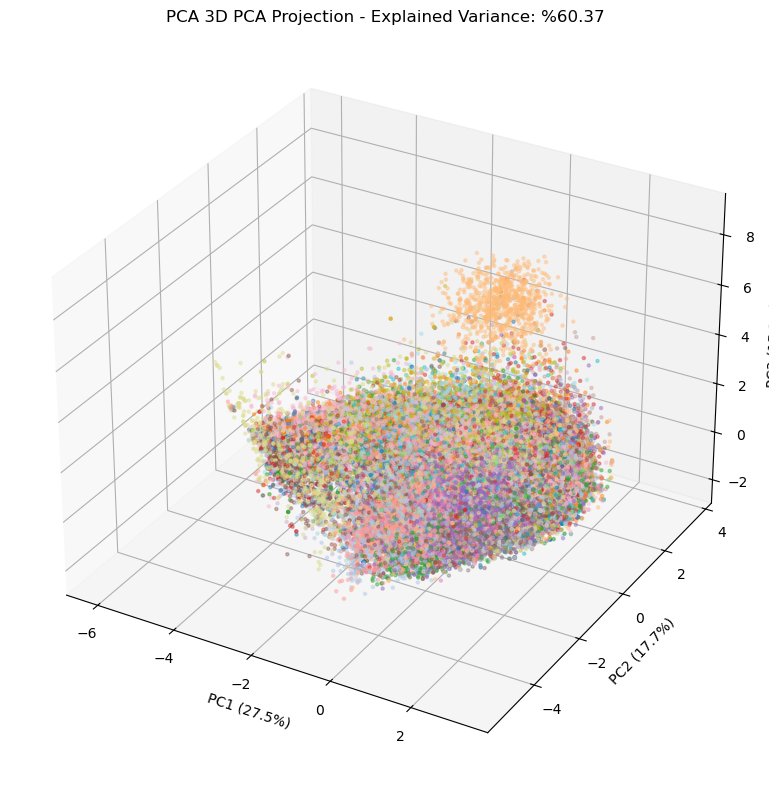

In [7]:
# Reduce data to 3 dimensions using PCA and visualizes genre distributions in a 3D scatter plot
pca_3d = PCA(n_components=3, random_state=42)
data_pca_3d = pca_3d.fit_transform(data_scaled)

total_var = pca_3d.explained_variance_ratio_.sum() * 100
print(f"Total Explained Variance (PC1+PC2+PC3): %{total_var:.2f}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d') 

scatter = ax.scatter(data_pca_3d[:, 0], data_pca_3d[:, 1], data_pca_3d[:, 2],c=pd.Categorical(df['track_genre']).codes, cmap='tab20', alpha=0.4, s=5)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")

ax.set_title(f'PCA 3D PCA Projection - Explained Variance: %{total_var:.2f}')

plt.tight_layout()
plt.show()

k=2  inertia=737544  silhouette=0.2228
k=3  inertia=647994  silhouette=0.1785
k=4  inertia=578024  silhouette=0.1886
k=5  inertia=529199  silhouette=0.1787
k=6  inertia=479524  silhouette=0.2041
k=7  inertia=434130  silhouette=0.2074
k=8  inertia=405749  silhouette=0.2107
k=9  inertia=380233  silhouette=0.2006
k=10  inertia=363458  silhouette=0.1856


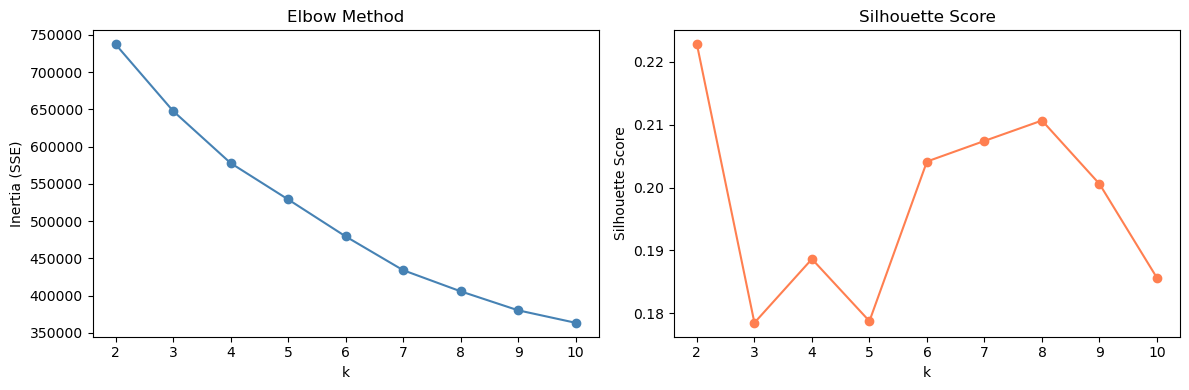

In [8]:
# Find the optimal number of clusters by comparing error (Inertia) and separation (Silhouette) across different k-values
inertia_list = []
silhouette_list = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(data_scaled, labels, sample_size=10000)
    silhouette_list.append(sil)
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertia_list, marker='o', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia (SSE)')
ax1.set_title('Elbow Method')

ax2.plot(list(K_RANGE), silhouette_list, marker='o', color='coral')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_k_selection.png', dpi=150)
plt.show()

In [9]:
# Choose k=8 and run K-means
km_final = KMeans(n_clusters=8, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(data_scaled)

print(df['cluster'].value_counts().sort_index())

cluster
0     7629
1    21688
2    24915
3    33203
4      936
5    11289
6     7375
7     6965
Name: count, dtype: int64


In [10]:
# Interpret the typical characteristics of each cluster
centers = scaler.inverse_transform(km_final.cluster_centers_)
df_centers = pd.DataFrame(centers, columns=FEATURES)
df_centers.index.name = 'cluster'
print(df_centers.round(3))

         danceability  energy  speechiness  acousticness  instrumentalness  \
cluster                                                                      
0               0.517   0.748        0.082         0.292             0.073   
1               0.518   0.368        0.046         0.697             0.021   
2               0.468   0.807        0.072         0.069             0.032   
3               0.695   0.724        0.063         0.210             0.021   
4               0.561   0.696        0.880         0.774             0.008   
5               0.585   0.758        0.070         0.087             0.787   
6               0.367   0.189        0.051         0.857             0.845   
7               0.701   0.671        0.308         0.262             0.025   

         liveness  valence    tempo  
cluster                              
0           0.746    0.504  123.042  
1           0.156    0.374  112.437  
2           0.192    0.362  138.790  
3           0.165    0.708  1

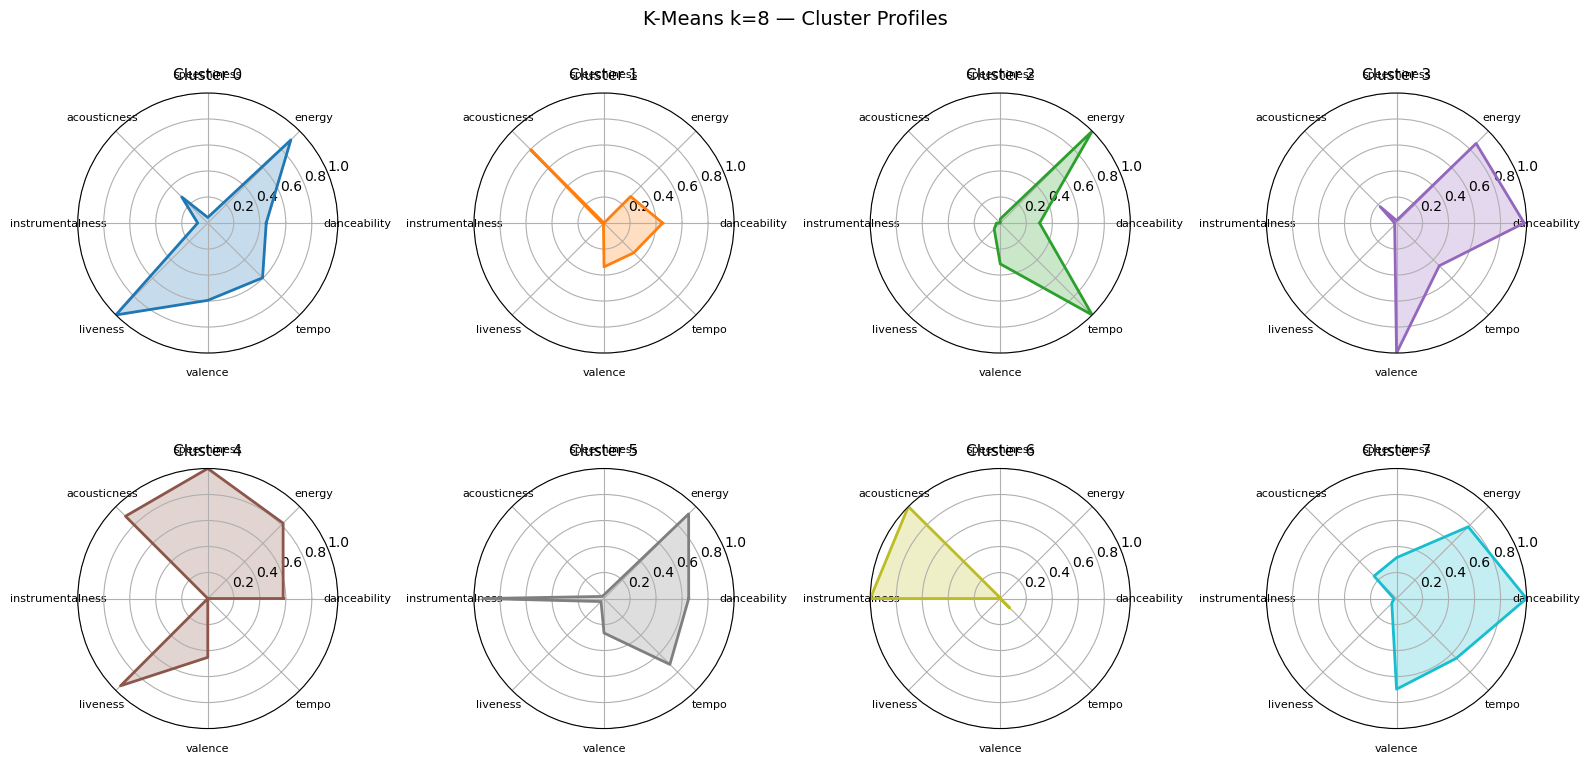

In [11]:
# Generates radar charts to visualize and compare the unique characteristic profiles of each music cluster.
df_radar = (df_centers - df_centers.min()) / (df_centers.max() - df_centers.min())

labels = FEATURES
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                          subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for i, ax in enumerate(axes.flat):
    values = df_radar.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:N])
    ax.set_xticklabels(labels, size=8)
    ax.set_title(f'Cluster {i}', size=11, pad=10)
    ax.set_ylim(0, 1)

plt.suptitle('K-Means k=8 — Cluster Profiles', size=14)
plt.tight_layout()
plt.savefig('kmeans_radar.png', dpi=150)
plt.show()

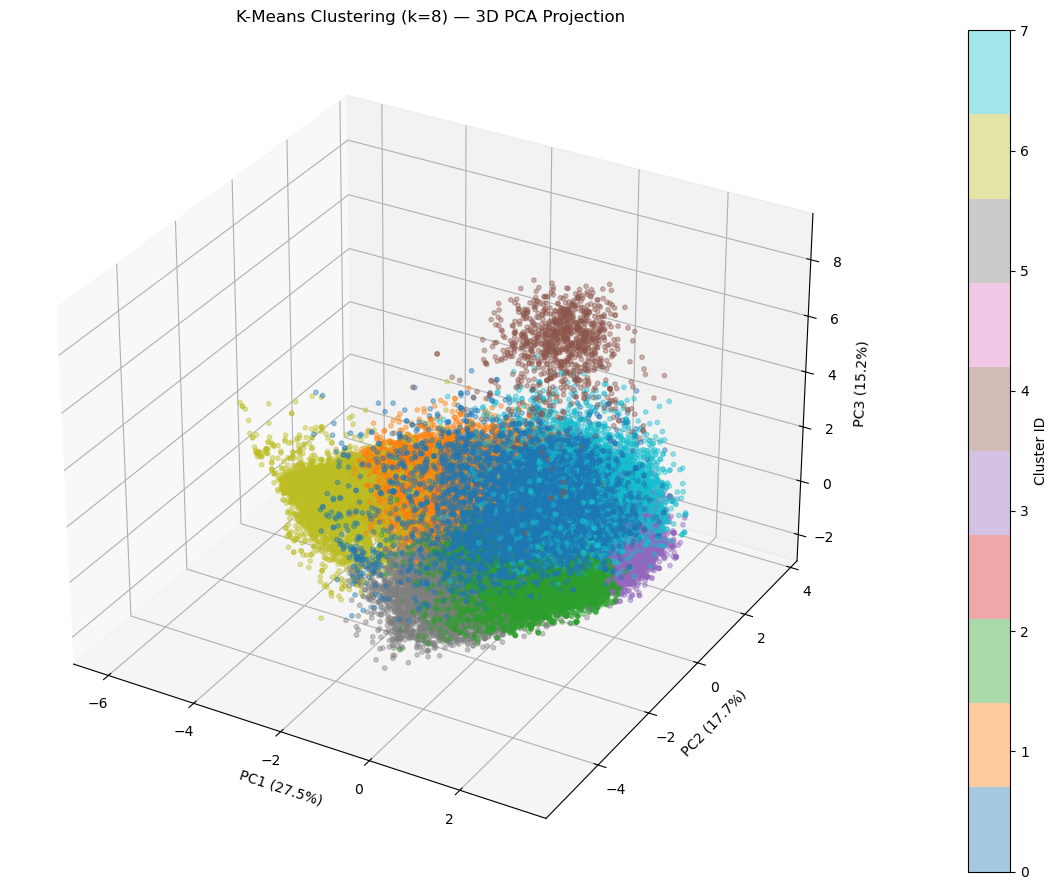

In [12]:
# Project the 8 identified clusters into a 3D coordinate system to evaluate spatial separation and cluster density.
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    data_pca_3d[:, 0], 
    data_pca_3d[:, 1], 
    data_pca_3d[:, 2],
    c=df['cluster'], 
    cmap='tab10', 
    alpha=0.4, 
    s=10
)

cb = plt.colorbar(scatter, ax=ax, pad=0.1)
cb.set_label('Cluster ID')

ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})")

ax.set_title('K-Means Clustering (k=8) — 3D PCA Projection')

plt.tight_layout()
plt.savefig('kmeans_pca_3d_scatter.png', dpi=150)
plt.show()

In [13]:
for i in range(8):
    top_genres = (df[df['cluster'] == i]['track_genre']
                  .value_counts()
                  .head(5))
    print(f"\n--- Cluster {i} ---")
    print(top_genres)


--- Cluster 0 ---
track_genre
pagode       503
sertanejo    434
samba        417
mpb          275
gospel       217
Name: count, dtype: int64

--- Cluster 1 ---
track_genre
romance       813
jazz          740
tango         723
honky-tonk    709
cantopop      659
Name: count, dtype: int64

--- Cluster 2 ---
track_genre
metalcore      832
heavy-metal    724
grunge         708
metal          689
dubstep        657
Name: count, dtype: int64

--- Cluster 3 ---
track_genre
salsa        820
latino       738
reggaeton    733
latin        725
reggae       724
Name: count, dtype: int64

--- Cluster 4 ---
track_genre
comedy        799
show-tunes     15
kids           14
children       12
jazz            7
Name: count, dtype: int64

--- Cluster 5 ---
track_genre
minimal-techno    859
detroit-techno    762
techno            623
grindcore         548
chicago-house     515
Name: count, dtype: int64

--- Cluster 6 ---
track_genre
new-age      759
classical    695
ambient      692
sleep        641
pian

In [15]:
# Stratified sampling: Select 40 tracks per genre to create a balanced subset for efficient visualization or analysis
sample_df = (df.groupby('track_genre', group_keys=False)
               .apply(lambda x: x.sample(n=40, random_state=42), include_groups=False))
sample_idx   = sample_df.index
X_sample     = data_scaled[sample_df.index.map(
                   lambda i: df.index.get_loc(i))]

positions    = [df.index.get_loc(i) for i in sample_idx]
X_sample     = data_scaled[positions]
print(f"Sample dimension: {X_sample.shape}")  # (4560, 8)

Sample dimension: (4560, 8)


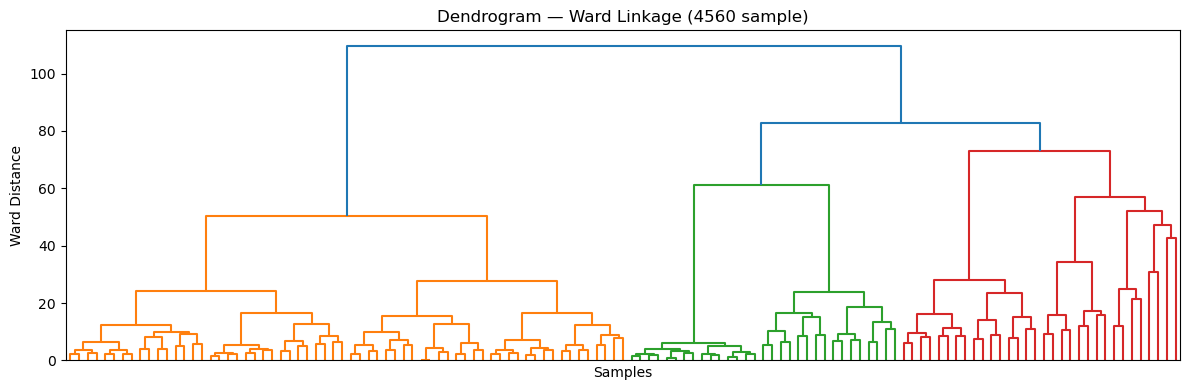

HC  silhouette    : 0.1518
HC  davies-bouldin: 1.4787
0    2053
1     486
2     626
3     268
4      33
5     319
6     337
7     438
Name: count, dtype: int64


In [16]:
# Run Hierarchical Clustering with selected k=8
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 4))
dendrogram(linked,
            truncate_mode='level', p=6,
            no_labels=True,
            color_threshold=0.7 * max(linked[:, 2]))
plt.title('Dendrogram — Ward Linkage (4560 sample)')
plt.xlabel('Samples')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# Select k=8
hc = AgglomerativeClustering(n_clusters=8, linkage='ward')
hc_labels = hc.fit_predict(X_sample)

hc_labels = hc.fit_predict(X_sample)

sil_hc = silhouette_score(X_sample, hc_labels)
db_hc  = davies_bouldin_score(X_sample, hc_labels)
print(f"HC  silhouette    : {sil_hc:.4f}")
print(f"HC  davies-bouldin: {db_hc:.4f}")

print(pd.Series(hc_labels).value_counts().sort_index())

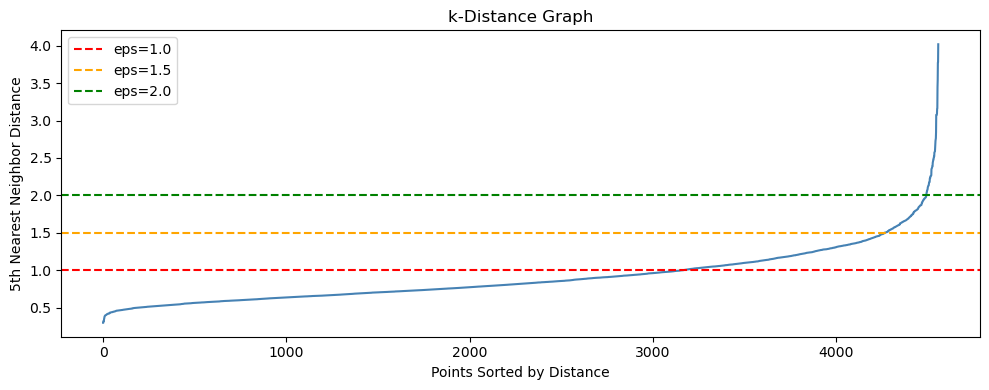

In [17]:
#Plot the k-Distance graph to visually identify the optimal eps value for DBSCAN by finding the "elbow" point
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)
dist_sorted  = np.sort(distances[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(dist_sorted, color='steelblue')
plt.axhline(1.0, color='red',    linestyle='--', label='eps=1.0')
plt.axhline(1.5, color='orange', linestyle='--', label='eps=1.5')
plt.axhline(2.0, color='green',  linestyle='--', label='eps=2.0')
plt.xlabel('Points Sorted by Distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('k-Distance Graph')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=150)
plt.show()

In [18]:
# Run DBSCAN Algorithm with selected eps value
EPS = 1.5  

dbscan = DBSCAN(eps=EPS, min_samples=10)
db_labels = dbscan.fit_predict(X_sample)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = list(db_labels).count(-1)
noise_pct     = n_noise / len(db_labels) * 100

print(f"Number of cluster: {n_clusters_db}")
print(f"Noise            : {n_noise} nokta ({noise_pct:.1f}%)")

mask = db_labels != -1
if n_clusters_db > 1:
    sil_db = silhouette_score(X_sample[mask], db_labels[mask])
    db_dbi = davies_bouldin_score(X_sample[mask], db_labels[mask])
    print(f"Silhouette Score     : {sil_db:.4f}")
    print(f"Davies-Bouldin Index : {db_dbi:.4f}")

Number of cluster: 2
Noise            : 224 nokta (4.9%)
Silhouette Score     : 0.6200
Davies-Bouldin Index : 0.4173


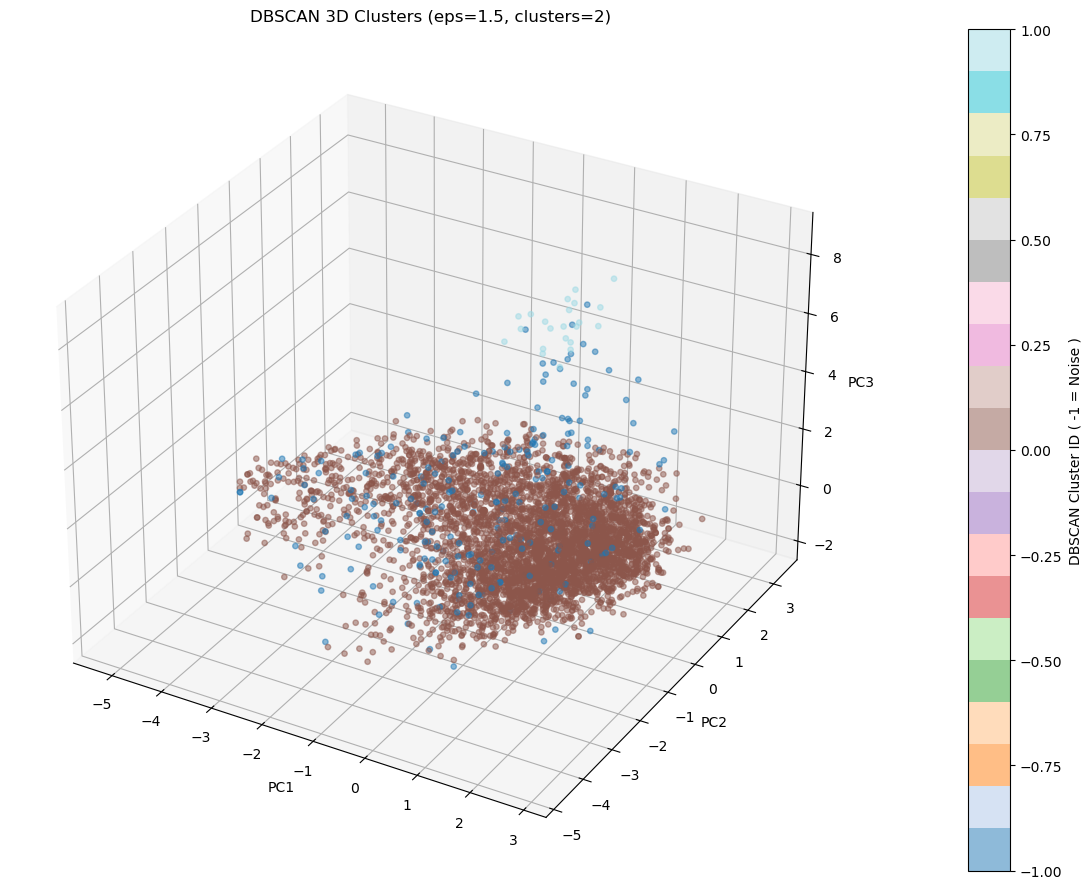

In [19]:
# Visualize DBSCAN clustering in 3D to identify density-based groups 
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    data_pca_3d[positions, 0], 
    data_pca_3d[positions, 1], 
    data_pca_3d[positions, 2],
    c=db_labels, 
    cmap='tab20', 
    alpha=0.5, 
    s=15
)

cb = plt.colorbar(scatter, ax=ax, pad=0.1)
cb.set_label('DBSCAN Cluster ID ( -1 = Noise )')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'DBSCAN 3D Clusters (eps={EPS}, clusters={n_clusters_db})')

plt.tight_layout()
plt.show()

In [20]:
# Compare the performance of K-Means, Hierarchical, and DBSCAN algorithms using Silhouette and Davies-Bouldin metrics to select the best model.
km_sample_labels = km_final.predict(X_sample)
sil_km  = silhouette_score(X_sample, km_sample_labels)
db_km   = davies_bouldin_score(X_sample, km_sample_labels)

results = pd.DataFrame({
    'Algorithm'    : ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Clusters'     : [8, 8, n_clusters_db],
    'Silhouette ↑' : [round(sil_km, 4),
                       round(sil_hc, 4),
                       round(sil_db, 4) if n_clusters_db > 1 else '—'],
    'Davies-Bouldin ↓': [round(db_km, 4),
                          round(db_hc, 4),
                          round(db_dbi, 4) if n_clusters_db > 1 else '—'],
    'Noise %'      : ['—', '—', f'{noise_pct:.1f}%'],
    'Full dataset' : ['Yes (114K)', 'No (4.5K)', 'No (4.5K)']
})

print(results.to_string(index=False))
results.to_csv('comparison_table.csv', index=False)

          Algorithm  Clusters  Silhouette ↑  Davies-Bouldin ↓ Noise % Full dataset
            K-Means         8        0.2113            1.3243       —   Yes (114K)
Hierarchical (Ward)         8        0.1518            1.4787       —    No (4.5K)
             DBSCAN         2        0.6200            0.4173    4.9%    No (4.5K)



**DEMONSTRATE HOW THESE PROFILES DRIVE PERSONALIZED RECOMMENDATION SYSTEMS**


In [25]:
# Map K-Means clusters to established Music Psychology personas and

PERSONA_MAP = {
    0: "Cultural / Traditional Listener",
    1: "Sophisticated / Reflective Listener",
    2: "Intense / Rebellious Listener",
    3: "Energetic / Social Dancer",
    4: "Mood-Lift / Casual Listener",
    5: "Flow / Electronic Immersion",
    6: "Calm / Focus Listener",
    7: "Rhythmic / Urban Dancer",
}

In [26]:
def predict_persona(track_features: dict) -> dict:
    """
    Predicts a listener persona based on the acoustic features of a track.
    
    track_features: dict containing the columns defined in FEATURES
    Example: {'danceability': 0.8, 'energy': 0.9, ...}
    """
    input_df = pd.DataFrame([track_features])[FEATURES]
    input_scaled = scaler.transform(input_df)
    
    cluster_id = km_final.predict(input_scaled)[0]
    primary_persona = PERSONA_MAP[cluster_id]
    
    distances = km_final.transform(input_scaled)[0]
    # Rank clusters by distance (closest is index 0, second closest is index 1)
    ranked_clusters = sorted(enumerate(distances), key=lambda x: x[1])
    secondary_persona = PERSONA_MAP[ranked_clusters[1][0]]

    print(f"Primary Persona   : {primary_persona}")
    print(f"Secondary Persona : {secondary_persona}")
    print(f"Cluster ID        : {cluster_id}")
    
    return {
        'cluster': cluster_id, 
        'persona': primary_persona,
        'secondary': secondary_persona
    }

# Example usage: a new track outside of the dataset
new_track = {
    'danceability': 0.85,
    'energy': 0.90,
    'speechiness': 0.08,
    'acousticness': 0.02,
    'instrumentalness': 0.00,
    'liveness': 0.15,
    'valence': 0.75,
    'tempo': 128.0,
}

predict_persona(new_track)

Primary Persona   : Energetic / Social Dancer
Secondary Persona : Rhythmic / Urban Dancer
Cluster ID        : 3


{'cluster': np.int32(3),
 'persona': 'Energetic / Social Dancer',
 'secondary': 'Rhythmic / Urban Dancer'}

In [27]:
def analyze_listener(listening_history: pd.DataFrame, 
                     top_n: int = 3) -> pd.DataFrame:
    """
    Generates a persona distribution from a user's listening history.
    
    listening_history: DataFrame containing columns defined in FEATURES
                       (e.g., a list of 100 recently played tracks)
    top_n: Number of personas to display in the summary
    """
    scaled_data = scaler.transform(listening_history[FEATURES])
    predicted_clusters = km_final.predict(scaled_data)
    
    cluster_counts = pd.Series(predicted_clusters).value_counts()
    total_tracks = len(predicted_clusters)
    
    results = pd.DataFrame({
        'Persona': [PERSONA_MAP[c] for c in cluster_counts.index],
        'Track Count': cluster_counts.values,
        'Percentage (%)': (cluster_counts.values / total_tracks * 100).round(1)
    })
    
    dominant_persona = results.iloc[0]['Persona']
    
    print(f"\n=== User Profile Analysis ===")
    print(f"Dominant Persona : {dominant_persona}")
    print(f"\nFull Distribution (Top {top_n}):")
    print(results.head(top_n).to_string(index=False))
    
    return results


=== User Profile Analysis ===
Dominant Persona : Flow / Electronic Immersion

Full Distribution (Top 3):
                      Persona  Track Count  Percentage (%)
  Flow / Electronic Immersion           53            53.0
    Energetic / Social Dancer           23            23.0
Intense / Rebellious Listener           13            13.0


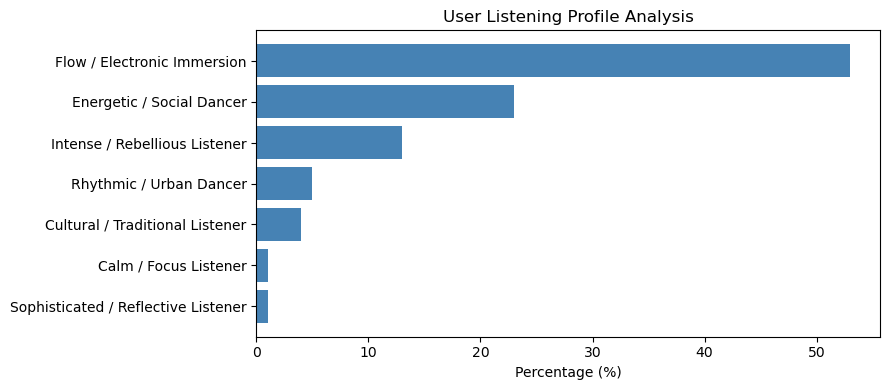

In [28]:
# Select 100 random tracks from the dataset to simulate a "user's listening history"
# For a realistic scenario, we sample heavily from specific electronic genres
user_history = (
    df[df['track_genre'].isin([
        'techno', 'house', 'electronic',
        'detroit-techno', 'minimal-techno'
    ])]
    .sample(n=100, random_state=42)
)

results = analyze_listener(user_history)

plt.figure(figsize=(9, 4))
plt.barh(results['Persona'], results['Percentage (%)'],
         color='steelblue', edgecolor='none')

plt.xlabel('Percentage (%)')
plt.title('User Listening Profile Analysis')
plt.gca().invert_yaxis() 
plt.tight_layout()

plt.savefig('user_profile_analysis.png', dpi=150)
plt.show()

In [29]:
def recommend_tracks(cluster_id: int, n: int = 5, 
                     exclude_idx=None) -> pd.DataFrame:
    """
    Recommends n tracks from a specific cluster/persona.
    """
    pool = df[df['cluster'] == cluster_id]
    
    if exclude_idx is not None:
        pool = pool[~pool.index.isin(exclude_idx)]
    
    recommendations = pool.sample(n=n, random_state=42)
    
    return recommendations[['track_name', 'artists', 'track_genre']]

# Example: A new track is assigned to a cluster → Recommend from the same persona
prediction_result = predict_persona(new_track)
recommended_list = recommend_tracks(prediction_result['cluster'], n=5)

print(f"\nRecommended tracks for the '{PERSONA_MAP[prediction_result['cluster']]}' persona:")
print(recommended_list.to_string(index=False))

Primary Persona   : Energetic / Social Dancer
Secondary Persona : Rhythmic / Urban Dancer
Cluster ID        : 3

Recommended tracks for the 'Energetic / Social Dancer' persona:
           track_name                  artists track_genre
                  Den                    Zuris         emo
           Bank Alert                 P-Square   dancehall
             Believer                 Fairlane     dubstep
      Costear - Remix Jhayco;Mariah Angeliq;Eq      reggae
Walk Like an Egyptian              The Bangles   synth-pop
